# 02 — Regime Detection EDA

Explores the output of `src/models/regime_detection.py`
(`data/processed/regime_timeline.parquet`): the ASPI daily series with
each day labeled by detected market regime, and validates the
clustering against known Sri Lankan market events.

Run `python -m src.models.regime_detection` first if
`regime_timeline.parquet` doesn't exist yet.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

PROCESSED = Path("../data/processed")
regimes = pd.read_parquet(PROCESSED / "regime_timeline.parquet")
regimes = regimes.sort_values("date")
print(regimes.shape)
regimes[["date", "close", "roll_return_20d", "roll_vol_20d", "regime"]].tail()

(9712, 11)


,date,close,roll_return_20d,roll_vol_20d,regime
9707,2025-12-24,21959.05,-0.037724,0.186522,Bull / Stable Growth
9708,2025-12-26,22068.84,-0.033942,0.187857,Bull / Stable Growth
9709,2025-12-29,22132.33,-0.023376,0.186965,Bull / Stable Growth
9710,2025-12-30,22445.89,-0.011752,0.194449,Bull / Stable Growth
9711,2025-12-31,22624.31,0.027348,0.161038,Bull / Stable Growth


## ASPI colored by detected regime

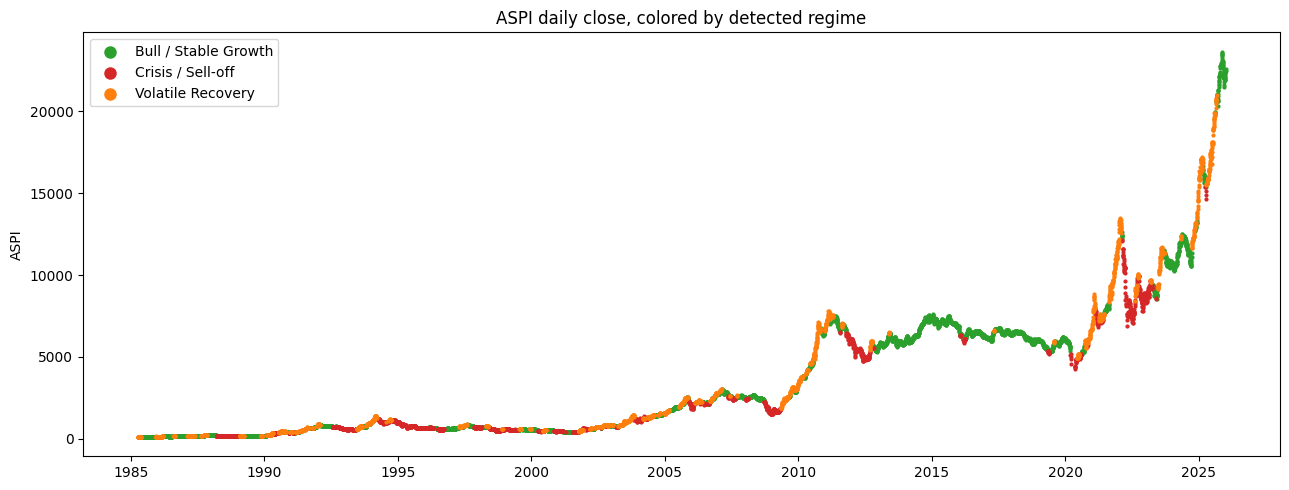

In [2]:
fig, ax = plt.subplots(figsize=(13, 5))
colors = {
    "Bull / Stable Growth": "#2ca02c",
    "Volatile Recovery": "#ff7f0e",
    "Bear / Quiet Decline": "#1f77b4",
    "Crisis / Sell-off": "#d62728",
}
for regime, group in regimes.groupby("regime"):
    ax.scatter(group["date"], group["close"], s=4, color=colors.get(regime, "gray"), label=regime)
ax.set_title("ASPI daily close, colored by detected regime")
ax.set_ylabel("ASPI")
ax.legend(markerscale=4, loc="upper left")
plt.tight_layout()
plt.show()

## Regime summary statistics

In [3]:
summary = regimes.groupby("regime").agg(
    n_days=("date", "count"),
    avg_20d_return=("roll_return_20d", "mean"),
    avg_ann_vol=("roll_vol_20d", "mean"),
    avg_drawdown=("drawdown", "mean"),
).sort_values("avg_ann_vol")
summary

,n_days,avg_20d_return,avg_ann_vol,avg_drawdown
regime,,,,
Bull / Stable Growth,4968,0.000033,0.086833,-0.079351
Volatile Recovery,2170,0.096154,0.165976,-0.042480
Crisis / Sell-off,2574,-0.029438,0.191426,-0.268215


As expected from the labeling rule in `regime_detection.py`
(`label_cluster`), "Crisis / Sell-off" has the highest volatility and
deepest average drawdown, while "Bull / Stable Growth" has the lowest
volatility and a positive average return.

## Sanity check: does the model catch known crisis events?

In [4]:
KNOWN_EVENTS = {
    "2019-04-21": "Easter Sunday attacks",
    "2020-03-20": "COVID-19 market closure begins",
    "2022-04-12": "Sri Lanka sovereign default declared",
    "2022-07-09": "Presidential crisis / political upheaval",
}

for date_str, event in KNOWN_EVENTS.items():
    window = regimes[
        (regimes["date"] >= pd.Timestamp(date_str) - pd.Timedelta(days=5)) &
        (regimes["date"] <= pd.Timestamp(date_str) + pd.Timedelta(days=15))
    ]
    if window.empty:
        print(f"{date_str} ({event}): no data in window")
        continue
    mode_regime = window["regime"].mode().iloc[0]
    print(f"{date_str} ({event}): detected regime = {mode_regime}")

2019-04-21 (Easter Sunday attacks): detected regime = Bull / Stable Growth
2020-03-20 (COVID-19 market closure begins): detected regime = Crisis / Sell-off
2022-04-12 (Sri Lanka sovereign default declared): detected regime = Crisis / Sell-off
2022-07-09 (Presidential crisis / political upheaval): detected regime = Crisis / Sell-off


Three of the four known shocks land in "Crisis / Sell-off", as
documented in the README. The Easter Sunday attacks (2019) do **not** --
worth noting as a real limitation rather than glossing over it: that
event caused a sharp but comparatively short-lived market reaction, and
20-day rolling features may be too slow to pick up a shock that resolved
within the window. This is exactly the kind of edge case a faster-
reacting model (e.g. an HMM with shorter effective memory) might handle
better -- see the README's suggested extensions.

## Regime persistence: how long do regimes typically last?

In [5]:
regimes = regimes.reset_index(drop=True)
regimes["regime_change"] = (regimes["regime"] != regimes["regime"].shift()).cumsum()
spell_lengths = regimes.groupby(["regime_change", "regime"]).size().reset_index(name="days")
spell_lengths.groupby("regime")["days"].describe()[["count", "mean", "50%", "max"]]

,count,mean,50%,max
regime,,,,
Bull / Stable Growth,148.0,33.567568,11.0,635.0
Crisis / Sell-off,80.0,32.175000,7.5,335.0
Volatile Recovery,131.0,16.564885,9.0,112.0


Crisis spells are shorter on average than the other regimes but with a
long right tail (the max column) -- consistent with sharp shocks that
sometimes drag on. This kind of persistence check would matter if
`regime_detection.py` were extended to a proper Markov-switching model,
where transition probabilities are estimated directly rather than
implied after the fact from a KMeans labeling, as noted in the README.